In [1]:
# =========================================================
# 0. 기본 설정
# =========================================================
import os
import json
import copy

import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import EfficientNet_B0_Weights

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_SIZE = 224
BATCH_SIZE = 32

STAGE1_EPOCHS = 10
FINE_EPOCHS = 5

LR_STAGE1 = 1e-3
LR_FINE = 1e-5

print("DEVICE:", DEVICE)

DEVICE: cuda


In [3]:
# =========================================================
# 1. 전처리 정의
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
# =========================================================
# 2. 모델 생성 (EfficientNetB0)
# =========================================================
def create_model(num_classes):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model.to(DEVICE)

In [6]:
# =========================================================
# 3. 학습 함수
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_correct = 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_correct += (out.argmax(1) == y).sum().item()

    return total_loss / len(loader.dataset), total_correct / len(loader.dataset)

In [12]:
# =========================================================
# 4. 평가 함수
# =========================================================
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item() * x.size(0)
            total_correct += (out.argmax(1) == y).sum().item()

    return total_loss / len(loader.dataset), total_correct / len(loader.dataset)

In [13]:
# =========================================================
# 15클래스 모델 (전체 코드)
# =========================================================

tag = "15cls"
train_dir = "/home/harry/plantvillage/PlantVillage"

# -------------------------
# 데이터 분할 (8:1:1)
# -------------------------
full_ds = datasets.ImageFolder(train_dir, transform=train_transform)

val_size = int(len(full_ds)*0.1)
test_size = int(len(full_ds)*0.1)
train_size = len(full_ds) - val_size - test_size

train_ds, val_ds, test_ds = torch.utils.data.random_split(
    full_ds,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE)

# -------------------------
# 클래스
# -------------------------
class_names = full_ds.classes
num_classes = len(class_names)

with open(f"class_names_{tag}.json","w") as f:
    json.dump(class_names, f)

# -------------------------
# 모델 생성
# -------------------------
model = create_model(num_classes)
criterion = nn.CrossEntropyLoss()

# -------------------------
# Stage1
# -------------------------
for p in model.features.parameters():
    p.requires_grad = False

optimizer = optim.Adam(model.parameters(), lr=LR_STAGE1)

best_acc = 0

for epoch in range(STAGE1_EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"[15cls Stage1 {epoch+1}] train:{tr_acc:.4f} val:{val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "cp_15cls_stage1.pth")

torch.save(model.state_dict(), "model_reaf_ai_effb0_15cls_stage1.pth")

test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"[15cls Stage1 TEST] acc:{test_acc:.4f}")

# -------------------------
# Fine-tune
# -------------------------
for p in model.parameters():
    p.requires_grad = False

for p in model.classifier.parameters():
    p.requires_grad = True

layers = list(model.features.children())
for layer in layers[-20:]:
    for p in layer.parameters():
        p.requires_grad = True

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_FINE)

best_acc = 0

for epoch in range(FINE_EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"[15cls Fine {epoch+1}] train:{tr_acc:.4f} val:{val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "cp_15cls_finetuned.pth")

torch.save(model.state_dict(), "model_reaf_ai_effb0_15cls_finetuned.pth")

test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"[15cls Fine TEST] acc:{test_acc:.4f}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/harry/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|███████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:00<00:00, 106MB/s]


[15cls Stage1 1] train:0.8074 val:0.9171
[15cls Stage1 2] train:0.8951 val:0.9336
[15cls Stage1 3] train:0.9069 val:0.9433
[15cls Stage1 4] train:0.9148 val:0.9433
[15cls Stage1 5] train:0.9159 val:0.9510
[15cls Stage1 6] train:0.9241 val:0.9506
[15cls Stage1 7] train:0.9232 val:0.9544
[15cls Stage1 8] train:0.9277 val:0.9564
[15cls Stage1 9] train:0.9302 val:0.9433
[15cls Stage1 10] train:0.9320 val:0.9530
[15cls Stage1 TEST] acc:0.9593
[15cls Fine 1] train:0.9446 val:0.9675
[15cls Fine 2] train:0.9606 val:0.9738
[15cls Fine 3] train:0.9688 val:0.9806
[15cls Fine 4] train:0.9762 val:0.9835
[15cls Fine 5] train:0.9792 val:0.9855
[15cls Fine TEST] acc:0.9869


In [ ]:
# =========================================================
# 38클래스 모델 (전체 코드)
# =========================================================

tag = "38cls"
train_dir = "/home/harry/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
val_dir   = "/home/harry/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

# -------------------------
# 데이터 로드 + val/test 분리
# -------------------------
train_ds = datasets.ImageFolder(train_dir, transform=train_transform)
val_full = datasets.ImageFolder(val_dir, transform=val_transform)

val_size = int(len(val_full)*0.5)
test_size = len(val_full) - val_size

val_ds, test_ds = torch.utils.data.random_split(
    val_full,
    [val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE)

# -------------------------
# 클래스
# -------------------------
class_names = train_ds.classes
num_classes = len(class_names)

with open(f"class_names_{tag}.json","w") as f:
    json.dump(class_names, f)

# -------------------------
# 모델 생성
# -------------------------
model = create_model(num_classes)
criterion = nn.CrossEntropyLoss()

# -------------------------
# Stage1
# -------------------------
for p in model.features.parameters():
    p.requires_grad = False

optimizer = optim.Adam(model.parameters(), lr=LR_STAGE1)

best_acc = 0

for epoch in range(STAGE1_EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"[38cls Stage1 {epoch+1}] train:{tr_acc:.4f} val:{val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "cp_38cls_stage1.pth")

torch.save(model.state_dict(), "model_reaf_ai_effb0_38cls_stage1.pth")

test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"[38cls Stage1 TEST] acc:{test_acc:.4f}")

# -------------------------
# Fine-tune
# -------------------------
for p in model.parameters():
    p.requires_grad = False

for p in model.classifier.parameters():
    p.requires_grad = True

layers = list(model.features.children())
for layer in layers[-20:]:
    for p in layer.parameters():
        p.requires_grad = True

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_FINE)

best_acc = 0

for epoch in range(FINE_EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"[38cls Fine {epoch+1}] train:{tr_acc:.4f} val:{val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "cp_38cls_finetuned.pth")

torch.save(model.state_dict(), "model_reaf_ai_effb0_38cls_finetuned.pth")

test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"[38cls Fine TEST] acc:{test_acc:.4f}")

KeyboardInterrupt: 

In [15]:
# =========================================================
# 실제 이미지 테스트 함수 (Top-5 + threshold)
# =========================================================
def predict_image(model, class_names, img_path, tag, threshold=0.7):

    model.eval()

    img = Image.open(img_path).convert("RGB")
    x = val_transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out = model(x)
        prob = torch.softmax(out, dim=1)[0]

    top5 = torch.topk(prob, 5)

    print(f"\n===== [{tag}] 결과 =====")
    print("이미지:", img_path)

    for i in range(5):
        idx = top5.indices[i].item()
        conf = top5.values[i].item()
        print(f"{i+1}위: {class_names[idx]} / {conf:.4f}")

    best_conf = top5.values[0].item()
    best_idx = top5.indices[0].item()

    print("----- 최종 판단 -----")
    if best_conf < threshold:
        print(f"판단 어려움 (신뢰도: {best_conf:.2f})")
    else:
        print(f"{class_names[best_idx]} (신뢰도: {best_conf:.2f})")

/tmp/ipykernel_290524/1876668232.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weight_path, map_location=DEVICE))



테스트 이미지: /home/harry/Re_leaf_Project/Test_image/전기역병1.jpg


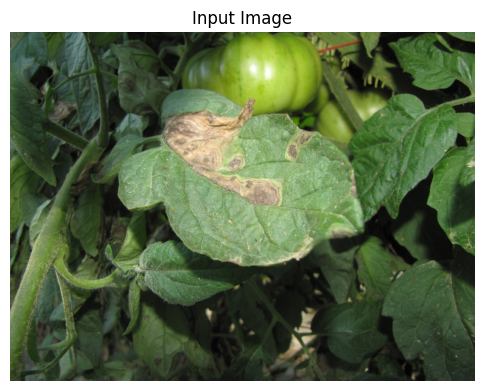


===== [15cls Stage1] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/전기역병1.jpg
1위: Tomato_Late_blight / 0.6785
2위: Pepper__bell___healthy / 0.2284
3위: Tomato_Early_blight / 0.0201
4위: Tomato_Leaf_Mold / 0.0183
5위: Tomato__Target_Spot / 0.0157
----- 최종 판단 -----
판단 어려움 (신뢰도: 0.68)

===== [15cls Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/전기역병1.jpg
1위: Tomato_Late_blight / 0.8362
2위: Pepper__bell___healthy / 0.1082
3위: Tomato_Early_blight / 0.0216
4위: Pepper__bell___Bacterial_spot / 0.0091
5위: Potato___Early_blight / 0.0083
----- 최종 판단 -----
Tomato_Late_blight (신뢰도: 0.84)

===== [38cls Stage1] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/전기역병1.jpg
1위: Tomato___Late_blight / 0.9005
2위: Potato___Early_blight / 0.0283
3위: Grape___Esca_(Black_Measles) / 0.0256
4위: Pepper,_bell___Bacterial_spot / 0.0089
5위: Pepper,_bell___healthy / 0.0083
----- 최종 판단 -----
Tomato___Late_blight (신뢰도: 0.90)

===== [38cls Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/전기역병

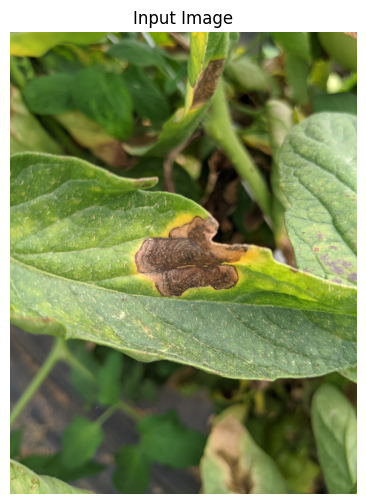


===== [15cls Stage1] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/전기역병2.jpg
1위: Tomato_Late_blight / 0.4750
2위: Potato___Late_blight / 0.2129
3위: Tomato_Early_blight / 0.2008
4위: Pepper__bell___Bacterial_spot / 0.1060
5위: Tomato_Leaf_Mold / 0.0025
----- 최종 판단 -----
판단 어려움 (신뢰도: 0.48)

===== [15cls Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/전기역병2.jpg
1위: Tomato_Early_blight / 0.3832
2위: Tomato_Late_blight / 0.2788
3위: Pepper__bell___Bacterial_spot / 0.2717
4위: Potato___Late_blight / 0.0647
5위: Tomato_Septoria_leaf_spot / 0.0006
----- 최종 판단 -----
판단 어려움 (신뢰도: 0.38)

===== [38cls Stage1] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/전기역병2.jpg
1위: Strawberry___Leaf_scorch / 0.3079
2위: Tomato___Early_blight / 0.2475
3위: Pepper,_bell___Bacterial_spot / 0.1781
4위: Potato___Late_blight / 0.1766
5위: Tomato___Late_blight / 0.0459
----- 최종 판단 -----
판단 어려움 (신뢰도: 0.31)

===== [38cls Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/전기역병2.jpg
1위: Tomato___Ear

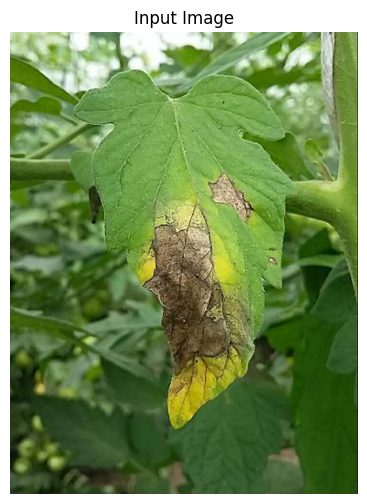


===== [15cls Stage1] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/후기역병1.jpg
1위: Tomato_Late_blight / 0.9992
2위: Potato___Late_blight / 0.0008
3위: Tomato_Septoria_leaf_spot / 0.0000
4위: Tomato_Leaf_Mold / 0.0000
5위: Tomato_Early_blight / 0.0000
----- 최종 판단 -----
Tomato_Late_blight (신뢰도: 1.00)

===== [15cls Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/후기역병1.jpg
1위: Tomato_Late_blight / 0.9999
2위: Potato___Late_blight / 0.0001
3위: Tomato_Septoria_leaf_spot / 0.0000
4위: Tomato_Early_blight / 0.0000
5위: Pepper__bell___Bacterial_spot / 0.0000
----- 최종 판단 -----
Tomato_Late_blight (신뢰도: 1.00)

===== [38cls Stage1] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/후기역병1.jpg
1위: Tomato___Late_blight / 0.9999
2위: Potato___Late_blight / 0.0001
3위: Tomato___Early_blight / 0.0000
4위: Tomato___Septoria_leaf_spot / 0.0000
5위: Tomato___Leaf_Mold / 0.0000
----- 최종 판단 -----
Tomato___Late_blight (신뢰도: 1.00)

===== [38cls Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/

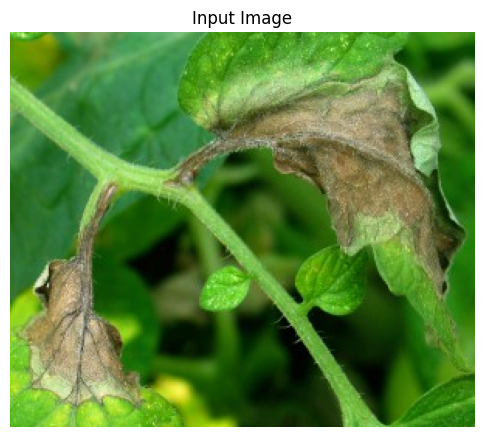


===== [15cls Stage1] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/후기역병2.jpg
1위: Tomato_Late_blight / 0.9998
2위: Tomato_Early_blight / 0.0001
3위: Pepper__bell___healthy / 0.0001
4위: Tomato_Septoria_leaf_spot / 0.0000
5위: Tomato_Leaf_Mold / 0.0000
----- 최종 판단 -----
Tomato_Late_blight (신뢰도: 1.00)

===== [15cls Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/후기역병2.jpg
1위: Tomato_Late_blight / 1.0000
2위: Pepper__bell___healthy / 0.0000
3위: Tomato_Early_blight / 0.0000
4위: Pepper__bell___Bacterial_spot / 0.0000
5위: Tomato_Septoria_leaf_spot / 0.0000
----- 최종 판단 -----
Tomato_Late_blight (신뢰도: 1.00)

===== [38cls Stage1] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/후기역병2.jpg
1위: Tomato___Late_blight / 0.9985
2위: Pepper,_bell___healthy / 0.0013
3위: Pepper,_bell___Bacterial_spot / 0.0001
4위: Tomato___Target_Spot / 0.0001
5위: Potato___Late_blight / 0.0000
----- 최종 판단 -----
Tomato___Late_blight (신뢰도: 1.00)

===== [38cls Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Te

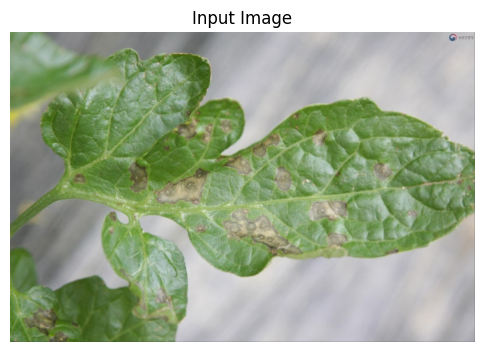


===== [15cls Stage1] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/점무늬병1.jpg
1위: Tomato_Late_blight / 0.5919
2위: Tomato__Tomato_YellowLeaf__Curl_Virus / 0.1457
3위: Tomato_Septoria_leaf_spot / 0.0756
4위: Tomato_Early_blight / 0.0612
5위: Tomato_Leaf_Mold / 0.0521
----- 최종 판단 -----
판단 어려움 (신뢰도: 0.59)

===== [15cls Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/점무늬병1.jpg
1위: Tomato_Late_blight / 0.6055
2위: Tomato_Septoria_leaf_spot / 0.2733
3위: Tomato_Early_blight / 0.0677
4위: Tomato__Tomato_YellowLeaf__Curl_Virus / 0.0201
5위: Potato___Late_blight / 0.0128
----- 최종 판단 -----
판단 어려움 (신뢰도: 0.61)

===== [38cls Stage1] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/점무늬병1.jpg
1위: Strawberry___Leaf_scorch / 0.8037
2위: Blueberry___healthy / 0.0684
3위: Grape___Black_rot / 0.0414
4위: Potato___Early_blight / 0.0369
5위: Tomato___Late_blight / 0.0224
----- 최종 판단 -----
Strawberry___Leaf_scorch (신뢰도: 0.80)

===== [38cls Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/

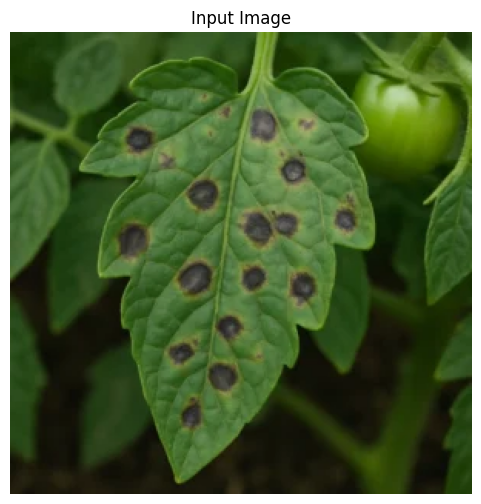


===== [15cls Stage1] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/점무늬병2.webp
1위: Tomato_Late_blight / 0.9851
2위: Pepper__bell___healthy / 0.0094
3위: Tomato__Tomato_YellowLeaf__Curl_Virus / 0.0016
4위: Pepper__bell___Bacterial_spot / 0.0012
5위: Tomato_Early_blight / 0.0011
----- 최종 판단 -----
Tomato_Late_blight (신뢰도: 0.99)

===== [15cls Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/점무늬병2.webp
1위: Tomato_Late_blight / 0.9864
2위: Pepper__bell___healthy / 0.0054
3위: Tomato_Septoria_leaf_spot / 0.0029
4위: Tomato_Early_blight / 0.0022
5위: Pepper__bell___Bacterial_spot / 0.0018
----- 최종 판단 -----
Tomato_Late_blight (신뢰도: 0.99)

===== [38cls Stage1] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/점무늬병2.webp
1위: Tomato___Late_blight / 0.3610
2위: Grape___Black_rot / 0.3468
3위: Pepper,_bell___healthy / 0.1030
4위: Cherry_(including_sour)___Powdery_mildew / 0.0727
5위: Blueberry___healthy / 0.0626
----- 최종 판단 -----
판단 어려움 (신뢰도: 0.36)

===== [38cls Fine] 결과 =====
이미지: /home/har

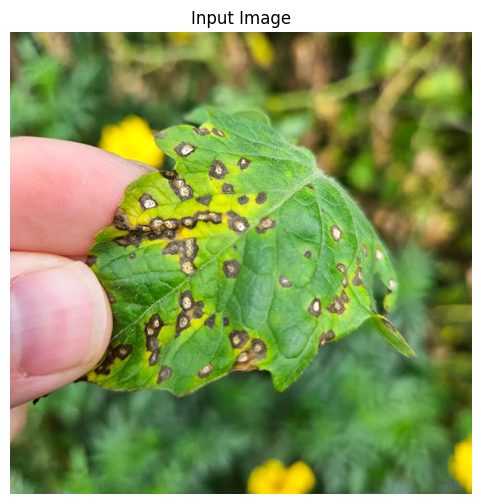


===== [15cls Stage1] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/셉토리아1.webp
1위: Tomato_Late_blight / 0.7007
2위: Tomato__Tomato_YellowLeaf__Curl_Virus / 0.1250
3위: Pepper__bell___Bacterial_spot / 0.0732
4위: Tomato_Bacterial_spot / 0.0353
5위: Tomato_Early_blight / 0.0245
----- 최종 판단 -----
Tomato_Late_blight (신뢰도: 0.70)

===== [15cls Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/셉토리아1.webp
1위: Tomato_Late_blight / 0.9374
2위: Pepper__bell___Bacterial_spot / 0.0328
3위: Tomato_Early_blight / 0.0115
4위: Tomato__Tomato_YellowLeaf__Curl_Virus / 0.0055
5위: Tomato_Bacterial_spot / 0.0048
----- 최종 판단 -----
Tomato_Late_blight (신뢰도: 0.94)

===== [38cls Stage1] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/셉토리아1.webp
1위: Apple___Black_rot / 0.9296
2위: Cherry_(including_sour)___Powdery_mildew / 0.0596
3위: Apple___Apple_scab / 0.0030
4위: Strawberry___Leaf_scorch / 0.0020
5위: Tomato___Late_blight / 0.0018
----- 최종 판단 -----
Apple___Black_rot (신뢰도: 0.93)

===== [38cls Fine] 결

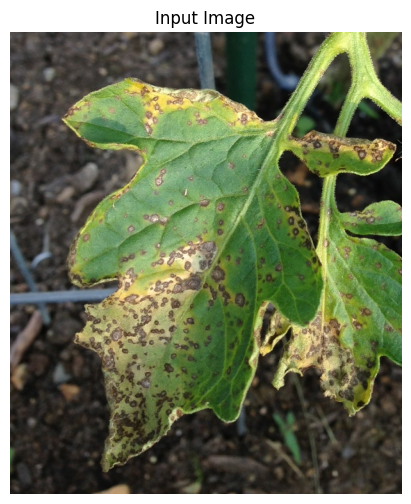


===== [15cls Stage1] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/셉토리아2.jpg
1위: Pepper__bell___healthy / 0.5791
2위: Tomato_Leaf_Mold / 0.0799
3위: Tomato__Tomato_mosaic_virus / 0.0758
4위: Pepper__bell___Bacterial_spot / 0.0673
5위: Tomato_Early_blight / 0.0488
----- 최종 판단 -----
판단 어려움 (신뢰도: 0.58)

===== [15cls Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/셉토리아2.jpg
1위: Pepper__bell___healthy / 0.3463
2위: Tomato_Early_blight / 0.1843
3위: Tomato_Septoria_leaf_spot / 0.1552
4위: Tomato_Late_blight / 0.1156
5위: Pepper__bell___Bacterial_spot / 0.0798
----- 최종 판단 -----
판단 어려움 (신뢰도: 0.35)

===== [38cls Stage1] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/셉토리아2.jpg
1위: Strawberry___Leaf_scorch / 0.6737
2위: Corn_(maize)___Northern_Leaf_Blight / 0.1196
3위: Tomato___Leaf_Mold / 0.0594
4위: Corn_(maize)___healthy / 0.0568
5위: Pepper,_bell___Bacterial_spot / 0.0227
----- 최종 판단 -----
판단 어려움 (신뢰도: 0.67)

===== [38cls Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image

In [19]:
# =========================================================
# 모델 로드 함수
# =========================================================
import json
import matplotlib.pyplot as plt

def load_model(weight_path, num_classes):
    model = create_model(num_classes)
    model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
    model.eval()
    return model
    
with open("class_names_15cls.json") as f:
    class_15 = json.load(f)

with open("class_names_38cls.json") as f:
    class_38 = json.load(f)
    
model_15_stage1 = load_model("model_reaf_ai_effb0_15cls_stage1.pth", len(class_15))
model_15_fine   = load_model("model_reaf_ai_effb0_15cls_finetuned.pth", len(class_15))
model_38_stage1 = load_model("model_reaf_ai_effb0_38cls_stage1.pth", len(class_38))
model_38_fine   = load_model("model_reaf_ai_effb0_38cls_finetuned.pth", len(class_38))


# 테스트 이미지 리스트
test_images = [
    "/home/harry/Re_leaf_Project/Test_image/전기역병1.jpg",
    "/home/harry/Re_leaf_Project/Test_image/전기역병2.jpg",
    "/home/harry/Re_leaf_Project/Test_image/후기역병1.jpg",
    "/home/harry/Re_leaf_Project/Test_image/후기역병2.jpg",
    "/home/harry/Re_leaf_Project/Test_image/점무늬병1.jpg",
    "/home/harry/Re_leaf_Project/Test_image/점무늬병2.webp",
    "/home/harry/Re_leaf_Project/Test_image/셉토리아1.webp",
    "/home/harry/Re_leaf_Project/Test_image/셉토리아2.jpg",
]

# =========================================================
# 이미지 1장 기준 4개 모델 비교
# =========================================================
# =========================================================
# 이미지 + 4개 모델 결과 같이 보기
# =========================================================
def compare_four_models(img_path, threshold=0.7):

    print("\n" + "=" * 80)
    print("테스트 이미지:", img_path)
    print("=" * 80)

    # -------------------------
    # 이미지 출력
    # -------------------------
    img = Image.open(img_path).convert("RGB")

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis("off")
    plt.show()

    # -------------------------
    # 모델 결과
    # -------------------------
    predict_image(model_15_stage1, class_15, img_path, tag="15cls Stage1", threshold=threshold)
    predict_image(model_15_fine,   class_15, img_path, tag="15cls Fine", threshold=threshold)

    predict_image(model_38_stage1, class_38, img_path, tag="38cls Stage1", threshold=threshold)
    predict_image(model_38_fine,   class_38, img_path, tag="38cls Fine", threshold=threshold)
    
for img_path in test_images:
    compare_four_models(img_path)

In [21]:
!pip install icrawler

  Using cached icrawler-0.6.10-py3-none-any.whl.metadata (6.2 kB)
  Using cached bs4-0.0.2-py2.py3-none-any.whl.metadata (411 bytes)
  Using cached lxml-6.1.0-cp311-cp311-manylinux_2_26_x86_64.manylinux_2_28_x86_64.whl.metadata (4.0 kB)
Using cached icrawler-0.6.10-py3-none-any.whl (36 kB)
Using cached bs4-0.0.2-py2.py3-none-any.whl (1.2 kB)
Using cached lxml-6.1.0-cp311-cp311-manylinux_2_26_x86_64.manylinux_2_28_x86_64.whl (5.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [icrawler]


In [22]:
# =========================================================
# 토마토 질병 실제 이미지 크롤링
# 4개 클래스 × 목표 약 200장
# =========================================================

from icrawler.builtin import GoogleImageCrawler, BingImageCrawler, FlickrImageCrawler
import os
import shutil

BASE_DIR = "tomato_real_raw"
TEMP_DIR = "tomato_crawl_temp"

classes = {
    "bacterial_spot": [
        "tomato bacterial spot leaf",
        "tomato leaf bacterial spot disease",
        "tomato bacterial spot close up",
        "tomato bacterial spot field",
        "xanthomonas tomato bacterial spot leaf",
        "tomato bacterial speck spot leaf"
    ],
    "early_blight": [
        "tomato early blight leaf",
        "tomato leaf early blight disease",
        "tomato early blight close up",
        "tomato early blight field",
        "alternaria solani tomato leaf",
        "tomato concentric ring leaf spot early blight"
    ],
    "late_blight": [
        "tomato late blight leaf",
        "tomato leaf late blight disease",
        "tomato late blight close up",
        "tomato late blight field",
        "phytophthora infestans tomato leaf",
        "tomato leaf water soaked lesion late blight"
    ],
    "septoria_leaf_spot": [
        "tomato septoria leaf spot",
        "tomato leaf septoria disease",
        "tomato septoria leaf spot close up",
        "tomato septoria leaf spot field",
        "septoria lycopersici tomato leaf",
        "tomato small circular leaf spots septoria"
    ]
}

MAX_PER_KEYWORD = 25

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(TEMP_DIR, exist_ok=True)

for class_name, keywords in classes.items():
    print(f"\n==============================")
    print(f"{class_name} 수집 시작")
    print(f"==============================")

    class_save_dir = os.path.join(BASE_DIR, class_name)
    os.makedirs(class_save_dir, exist_ok=True)

    img_count = 0

    for keyword_idx, keyword in enumerate(keywords, start=1):
        print(f"\n키워드 {keyword_idx}: {keyword}")

        for engine_name, Crawler in [
            ("google", GoogleImageCrawler),
            ("bing", BingImageCrawler),
            ("flickr", FlickrImageCrawler)
        ]:
            temp_save_dir = os.path.join(
                TEMP_DIR,
                class_name,
                f"{engine_name}_{keyword_idx}"
            )

            os.makedirs(temp_save_dir, exist_ok=True)

            print(f"  {engine_name} 수집 중...")

            try:
                crawler = Crawler(storage={"root_dir": temp_save_dir})
                crawler.crawl(
                    keyword=keyword,
                    max_num=MAX_PER_KEYWORD
                )

                for fname in os.listdir(temp_save_dir):
                    if fname.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
                        src = os.path.join(temp_save_dir, fname)

                        ext = os.path.splitext(fname)[1].lower()
                        new_name = f"{class_name}_{engine_name}_{keyword_idx}_{img_count:04d}{ext}"
                        dst = os.path.join(class_save_dir, new_name)

                        shutil.copy(src, dst)
                        img_count += 1

            except Exception as e:
                print(f"  {engine_name} 오류 발생:", e)

    print(f"\n{class_name} 수집 완료: {img_count}장")

print("\n전체 수집 완료")

2026-04-30 14:36:39,456 - INFO - icrawler.crawler - start crawling...
2026-04-30 14:36:39,457 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-04-30 14:36:39,457 - INFO - feeder - thread feeder-001 exit
2026-04-30 14:36:39,457 - INFO - icrawler.crawler - starting 1 parser threads...
2026-04-30 14:36:39,458 - INFO - icrawler.crawler - starting 1 downloader threads...
2026-04-30 14:36:39,625 - INFO - parser - parsing result page https://www.google.com/search?q=tomato+bacterial+spot+leaf&ijn=0&start=0&tbs=&tbm=isch
Exception in thread parser-001:
Traceback (most recent call last):
  File "/home/harry/miniconda3/envs/pytorch_gpu/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/home/harry/miniconda3/envs/pytorch_gpu/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/home/harry/miniconda3/envs/pytorch_gpu/lib/python3.11/site-packages/icrawler/parser.py", line 93, in worker_exec
    for task in


bacterial_spot 수집 시작

키워드 1: tomato bacterial spot leaf
  google 수집 중...


2026-04-30 14:36:44,460 - INFO - downloader - no more download task for thread downloader-001
2026-04-30 14:36:44,462 - INFO - downloader - thread downloader-001 exit
2026-04-30 14:36:45,461 - INFO - icrawler.crawler - Crawling task done!
2026-04-30 14:36:45,464 - INFO - icrawler.crawler - start crawling...
2026-04-30 14:36:45,464 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-04-30 14:36:45,465 - INFO - feeder - thread feeder-001 exit
2026-04-30 14:36:45,466 - INFO - icrawler.crawler - starting 1 parser threads...
2026-04-30 14:36:45,468 - INFO - icrawler.crawler - starting 1 downloader threads...
2026-04-30 14:36:45,535 - INFO - parser - parsing result page https://www.bing.com/images/async?q=tomato bacterial spot leaf&first=0


  bing 수집 중...


2026-04-30 14:36:46,978 - INFO - parser - parsing result page https://www.bing.com/images/async?q=tomato bacterial spot leaf&first=20
2026-04-30 14:36:50,167 - INFO - downloader - image #1	https://apps.lucidcentral.org/pppw_v10/images/entities/tomato_bacterial_spot_081/fs81_bacterial_spot_page_1_image_0002.jpg
2026-04-30 14:36:51,454 - INFO - downloader - image #2	https://www.lsuagcenter.com/~/media/system/e/d/5/f/ed5f2bf2949a12ff123c460961e32e9a/bacterialspottomatoxant4.jpg
2026-04-30 14:36:53,394 - INFO - downloader - image #3	https://www.ontario.ca/files/2022-01/omafra-bacterial-diseases-of-tomato-figure-1-en-840x1136-2021-12-09-v1.jpg
2026-04-30 14:36:56,474 - INFO - downloader - image #4	https://ag.purdue.edu/department/arge/swpap/_media/bacterial-spot-of-tomato-1-original.jpg
2026-04-30 14:36:57,844 - INFO - downloader - image #5	https://pddc.webhosting.cals.wisc.edu/wp-content/uploads/sites/39/2017/02/Bacterial-Spot-of-Tomato-Img-2.jpg
2026-04-30 14:36:58,378 - INFO - downloader

...

2026-04-30 14:51:18,992 - INFO - parser - downloaded image reached max num, thread parser-001 is ready to exit
2026-04-30 14:51:18,993 - INFO - parser - thread parser-001 exit
2026-04-30 14:51:23,690 - INFO - downloader - no more download task for thread downloader-001
2026-04-30 14:51:23,692 - INFO - downloader - thread downloader-001 exit
2026-04-30 14:51:24,691 - INFO - icrawler.crawler - Crawling task done!
2026-04-30 14:51:24,695 - INFO - icrawler.crawler - start crawling...
2026-04-30 14:51:24,696 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-04-30 14:51:24,697 - INFO - feeder - thread feeder-001 exit
2026-04-30 14:51:24,697 - INFO - icrawler.crawler - starting 1 parser threads...
2026-04-30 14:51:24,699 - INFO - icrawler.crawler - starting 1 downloader threads...


  bing 수집 중...


2026-04-30 14:51:26,282 - INFO - parser - parsing result page https://www.bing.com/images/async?q=tomato small circular leaf spots septoria&first=0
2026-04-30 14:51:26,364 - INFO - downloader - image #1	https://images.ctfassets.net/zma7thmmcinb/6QD6o1tmZ4ynk7Vsi5V816/70afc15b6b692562293b5e4d382d7222/septoria-leaf-spot_jennifer-howell_tomato-problems_lead.jpg
2026-04-30 14:51:26,446 - INFO - downloader - image #2	https://fthmb.tqn.com/_Tn4Rdp1q8gD6v4ocNR6LEOn454=/960x0/filters:no_upscale()/Spetoria-Leaf-Spot-56a348bf3df78cf7727cb35b.jpg
2026-04-30 14:51:28,131 - INFO - downloader - image #3	http://www.missouribotanicalgarden.org/portals/0/Gardening/Gardening Help/images/Pests/Septoria_Leaf_Spot_of_Tomato186.jpg
2026-04-30 14:51:28,733 - INFO - downloader - image #4	https://pestsdiseases.com/wp-content/uploads/Septoria-Leaf-Spot-Management-in-Tomato-2.jpg
2026-04-30 14:51:28,869 - INFO - downloader - image #5	https://www.bhg.com/thmb/h3AJgr3gTqptcaEXIlFi--oBFB0=/1515x0/filters:no_upscale

  flickr 수집 중...
  flickr 오류 발생: apikey is not specified

septoria_leaf_spot 수집 완료: 150장

전체 수집 완료


2026-04-30 14:51:50,469 - INFO - parser - downloaded image reached max num, thread parser-001 is ready to exit
2026-04-30 14:51:50,471 - INFO - parser - thread parser-001 exit


In [23]:
import os

for class_name in os.listdir("tomato_real_raw"):
    class_dir = os.path.join("tomato_real_raw", class_name)
    if os.path.isdir(class_dir):
        print(class_name, ":", len(os.listdir(class_dir)), "장")

septoria_leaf_spot : 150 장
early_blight : 150 장
late_blight : 148 장
bacterial_spot : 143 장


In [24]:
# =========================================================
# 추가 학습용 실제 이미지 데이터 경로
# =========================================================

REAL_15_DIR = "/home/harry/Re_leaf_Project/tomato_real_15cls"
REAL_38_DIR = "/home/harry/Re_leaf_Project/tomato_real_38cls"

# =========================================================
# 기존 fine 모델에 실제 이미지 추가 학습
# =========================================================

def extra_train_finetuned_model(
    model_path,
    real_data_dir,
    class_names_path,
    save_path,
    cp_path,
    tag="15cls",
    epochs=5,
    lr=1e-5
):
    print(f"\n===== {tag} 추가 학습 시작 =====")

    # 클래스 이름 불러오기
    with open(class_names_path, "r", encoding="utf-8") as f:
        class_names = json.load(f)

    num_classes = len(class_names)

    # 모델 생성 후 기존 fine 가중치 로드
    model = create_model(num_classes)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model = model.to(DEVICE)

    # 실제 이미지 데이터셋 로드
    full_ds = datasets.ImageFolder(real_data_dir, transform=train_transform)

    print(f"[{tag}] 실제 이미지 클래스 수:", len(full_ds.classes))
    print(f"[{tag}] 실제 이미지 수:", len(full_ds))

    # train / val 분리
    val_size = int(len(full_ds) * 0.2)
    train_size = len(full_ds) - val_size

    train_ds, val_ds = torch.utils.data.random_split(
        full_ds,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

    # 전체 freeze
    for p in model.parameters():
        p.requires_grad = False

    # classifier 학습
    for p in model.classifier.parameters():
        p.requires_grad = True

    # 뒤쪽 레이어 일부 학습
    layers = list(model.features.children())
    for layer in layers[-20:]:
        for p in layer.parameters():
            p.requires_grad = True

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    best_acc = 0

    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        print(f"[{tag} Extra {epoch+1}/{epochs}] train:{tr_acc:.4f} val:{val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), cp_path)
            print(f"[{tag}] 추가학습 checkpoint 저장:", cp_path)

    # 최종 저장
    torch.save(model.state_dict(), save_path)
    print(f"[{tag}] 추가학습 최종 모델 저장:", save_path)

    return model, class_names

In [25]:
#15 클래스
model_15_extra, class_15 = extra_train_finetuned_model(
    model_path="model_reaf_ai_effb0_15cls_finetuned.pth",
    real_data_dir=REAL_15_DIR,
    class_names_path="class_names_15cls.json",
    save_path="model_reaf_ai_effb0_15cls_extra_finetuned.pth",
    cp_path="cp_15cls_extra_finetuned.pth",
    tag="15cls",
    epochs=5,
    lr=1e-5
)


===== 15cls 추가 학습 시작 =====
[15cls] 실제 이미지 클래스 수: 4
[15cls] 실제 이미지 수: 406


/tmp/ipykernel_290524/1400602173.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=DEVICE))


[15cls Extra 1/5] train:0.0123 val:0.0000
[15cls Extra 2/5] train:0.0215 val:0.0370
[15cls] 추가학습 checkpoint 저장: cp_15cls_extra_finetuned.pth
[15cls Extra 3/5] train:0.0215 val:0.0247
[15cls Extra 4/5] train:0.0338 val:0.0247
[15cls Extra 5/5] train:0.0369 val:0.0247
[15cls] 추가학습 최종 모델 저장: model_reaf_ai_effb0_15cls_extra_finetuned.pth


In [26]:
model_38_extra, class_38 = extra_train_finetuned_model(
    model_path="model_reaf_ai_effb0_38cls_finetuned.pth",
    real_data_dir=REAL_38_DIR,
    class_names_path="class_names_38cls.json",
    save_path="model_reaf_ai_effb0_38cls_extra_finetuned.pth",
    cp_path="cp_38cls_extra_finetuned.pth",
    tag="38cls",
    epochs=5,
    lr=1e-5
)


===== 38cls 추가 학습 시작 =====
[38cls] 실제 이미지 클래스 수: 4
[38cls] 실제 이미지 수: 406


/tmp/ipykernel_290524/1400602173.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=DEVICE))


[38cls Extra 1/5] train:0.0154 val:0.0247
[38cls] 추가학습 checkpoint 저장: cp_38cls_extra_finetuned.pth
[38cls Extra 2/5] train:0.0338 val:0.0247
[38cls Extra 3/5] train:0.0185 val:0.0494
[38cls] 추가학습 checkpoint 저장: cp_38cls_extra_finetuned.pth
[38cls Extra 4/5] train:0.0338 val:0.0370
[38cls Extra 5/5] train:0.0462 val:0.0370
[38cls] 추가학습 최종 모델 저장: model_reaf_ai_effb0_38cls_extra_finetuned.pth


/tmp/ipykernel_290524/1876668232.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weight_path, map_location=DEVICE))



테스트 이미지: /home/harry/Re_leaf_Project/Test_image/전기역병1.jpg


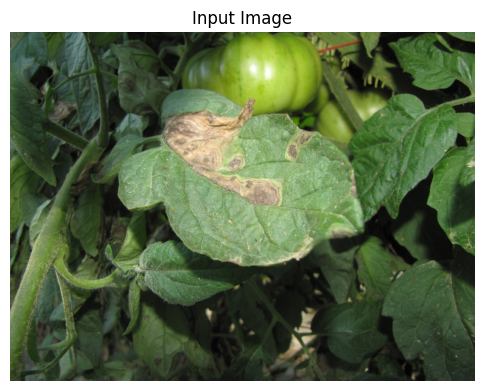


===== [15cls Extra Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/전기역병1.jpg
1위: Tomato_Late_blight / 0.2574
2위: Tomato_Bacterial_spot / 0.1923
3위: Tomato_Early_blight / 0.1636
4위: Tomato__Target_Spot / 0.1463
5위: Tomato_Spider_mites_Two_spotted_spider_mite / 0.1344
----- 최종 판단 -----
판단 어려움 (신뢰도: 0.26)

===== [38cls Extra Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/전기역병1.jpg
1위: Cherry_(including_sour)___Powdery_mildew / 0.2869
2위: Apple___Black_rot / 0.2375
3위: Tomato___Early_blight / 0.1978
4위: Tomato___Late_blight / 0.1279
5위: Tomato___Target_Spot / 0.0911
----- 최종 판단 -----
판단 어려움 (신뢰도: 0.29)

테스트 이미지: /home/harry/Re_leaf_Project/Test_image/전기역병2.jpg


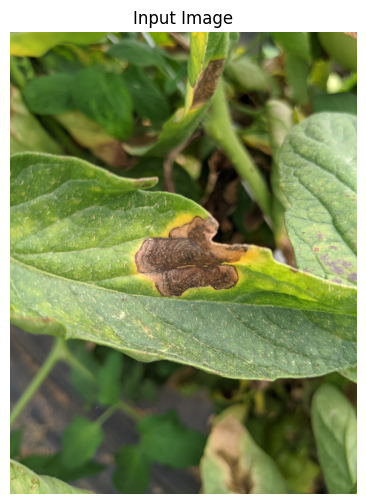


===== [15cls Extra Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/전기역병2.jpg
1위: Tomato_Early_blight / 0.5555
2위: Tomato_Late_blight / 0.1292
3위: Tomato_Septoria_leaf_spot / 0.0814
4위: Pepper__bell___Bacterial_spot / 0.0714
5위: Tomato__Target_Spot / 0.0692
----- 최종 판단 -----
판단 어려움 (신뢰도: 0.56)

===== [38cls Extra Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/전기역병2.jpg
1위: Tomato___Early_blight / 0.9580
2위: Pepper,_bell___Bacterial_spot / 0.0230
3위: Tomato___Septoria_leaf_spot / 0.0128
4위: Tomato___Late_blight / 0.0017
5위: Tomato___Target_Spot / 0.0014
----- 최종 판단 -----
Tomato___Early_blight (신뢰도: 0.96)

테스트 이미지: /home/harry/Re_leaf_Project/Test_image/후기역병1.jpg


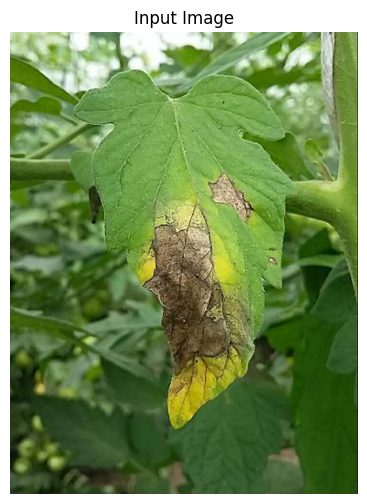


===== [15cls Extra Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/후기역병1.jpg
1위: Tomato_Late_blight / 0.6846
2위: Potato___Late_blight / 0.3133
3위: Tomato_Septoria_leaf_spot / 0.0017
4위: Tomato_Spider_mites_Two_spotted_spider_mite / 0.0002
5위: Potato___Early_blight / 0.0001
----- 최종 판단 -----
판단 어려움 (신뢰도: 0.68)

===== [38cls Extra Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/후기역병1.jpg
1위: Tomato___Late_blight / 0.9395
2위: Potato___Late_blight / 0.0577
3위: Tomato___Septoria_leaf_spot / 0.0022
4위: Tomato___Early_blight / 0.0001
5위: Tomato___Spider_mites Two-spotted_spider_mite / 0.0001
----- 최종 판단 -----
Tomato___Late_blight (신뢰도: 0.94)

테스트 이미지: /home/harry/Re_leaf_Project/Test_image/후기역병2.jpg


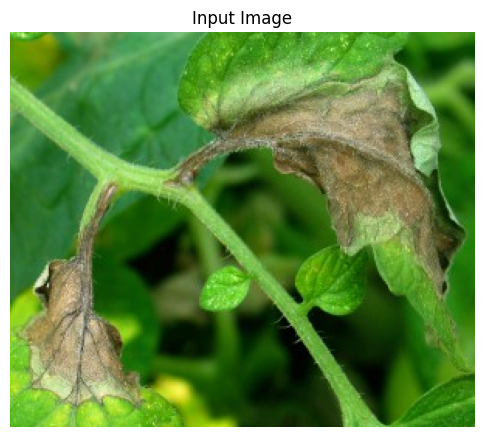


===== [15cls Extra Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/후기역병2.jpg
1위: Tomato_Late_blight / 0.8588
2위: Pepper__bell___healthy / 0.0947
3위: Tomato_Spider_mites_Two_spotted_spider_mite / 0.0266
4위: Tomato__Tomato_YellowLeaf__Curl_Virus / 0.0078
5위: Potato___Late_blight / 0.0045
----- 최종 판단 -----
Tomato_Late_blight (신뢰도: 0.86)

===== [38cls Extra Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/후기역병2.jpg
1위: Pepper,_bell___healthy / 0.7022
2위: Tomato___Late_blight / 0.2928
3위: Potato___Late_blight / 0.0032
4위: Cherry_(including_sour)___Powdery_mildew / 0.0009
5위: Tomato___Spider_mites Two-spotted_spider_mite / 0.0003
----- 최종 판단 -----
Pepper,_bell___healthy (신뢰도: 0.70)

테스트 이미지: /home/harry/Re_leaf_Project/Test_image/점무늬병1.jpg


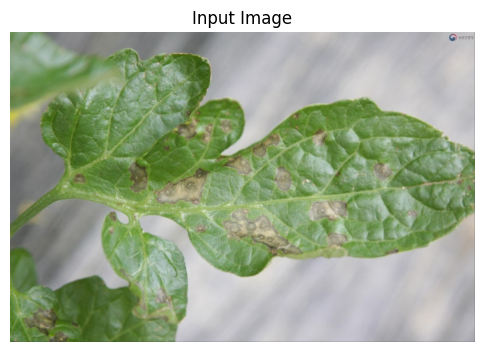


===== [15cls Extra Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/점무늬병1.jpg
1위: Potato___Late_blight / 0.9668
2위: Potato___healthy / 0.0242
3위: Tomato_Late_blight / 0.0038
4위: Tomato_Septoria_leaf_spot / 0.0022
5위: Tomato_Early_blight / 0.0021
----- 최종 판단 -----
Potato___Late_blight (신뢰도: 0.97)

===== [38cls Extra Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/점무늬병1.jpg
1위: Potato___Late_blight / 0.7774
2위: Apple___Apple_scab / 0.0857
3위: Potato___healthy / 0.0808
4위: Grape___healthy / 0.0222
5위: Soybean___healthy / 0.0189
----- 최종 판단 -----
Potato___Late_blight (신뢰도: 0.78)

테스트 이미지: /home/harry/Re_leaf_Project/Test_image/점무늬병2.webp


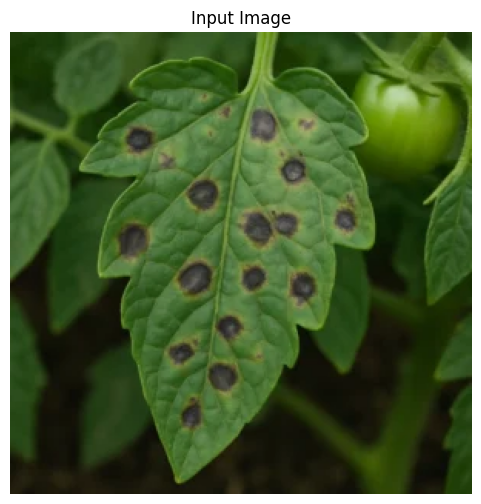


===== [15cls Extra Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/점무늬병2.webp
1위: Tomato_Late_blight / 0.7021
2위: Pepper__bell___Bacterial_spot / 0.1112
3위: Potato___healthy / 0.0692
4위: Tomato_Spider_mites_Two_spotted_spider_mite / 0.0423
5위: Tomato_Early_blight / 0.0294
----- 최종 판단 -----
Tomato_Late_blight (신뢰도: 0.70)

===== [38cls Extra Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/점무늬병2.webp
1위: Tomato___Early_blight / 0.6601
2위: Tomato___Late_blight / 0.2043
3위: Cherry_(including_sour)___Powdery_mildew / 0.0341
4위: Pepper,_bell___Bacterial_spot / 0.0279
5위: Potato___healthy / 0.0218
----- 최종 판단 -----
판단 어려움 (신뢰도: 0.66)

테스트 이미지: /home/harry/Re_leaf_Project/Test_image/셉토리아1.webp


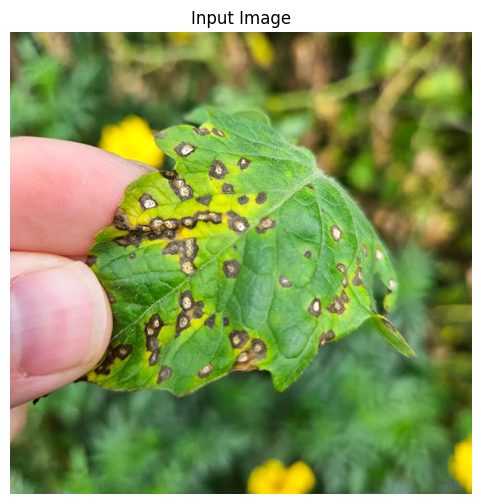


===== [15cls Extra Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/셉토리아1.webp
1위: Tomato_Bacterial_spot / 0.4923
2위: Tomato__Target_Spot / 0.3195
3위: Tomato_Early_blight / 0.0624
4위: Pepper__bell___Bacterial_spot / 0.0322
5위: Tomato__Tomato_YellowLeaf__Curl_Virus / 0.0228
----- 최종 판단 -----
판단 어려움 (신뢰도: 0.49)

===== [38cls Extra Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/셉토리아1.webp
1위: Apple___Black_rot / 0.6866
2위: Cherry_(including_sour)___Powdery_mildew / 0.1816
3위: Potato___healthy / 0.0347
4위: Tomato___Bacterial_spot / 0.0311
5위: Grape___Leaf_blight_(Isariopsis_Leaf_Spot) / 0.0143
----- 최종 판단 -----
판단 어려움 (신뢰도: 0.69)

테스트 이미지: /home/harry/Re_leaf_Project/Test_image/셉토리아2.jpg


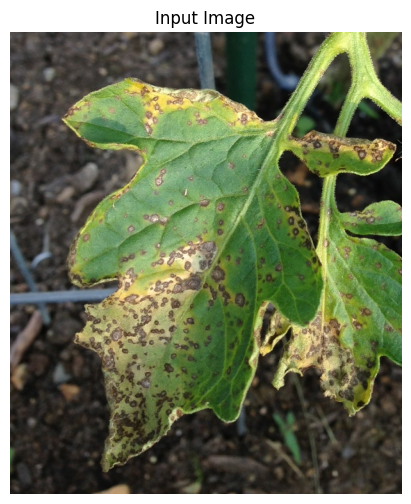


===== [15cls Extra Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/셉토리아2.jpg
1위: Pepper__bell___Bacterial_spot / 0.7294
2위: Pepper__bell___healthy / 0.1759
3위: Tomato_Septoria_leaf_spot / 0.0246
4위: Tomato_Early_blight / 0.0218
5위: Tomato_Spider_mites_Two_spotted_spider_mite / 0.0138
----- 최종 판단 -----
Pepper__bell___Bacterial_spot (신뢰도: 0.73)

===== [38cls Extra Fine] 결과 =====
이미지: /home/harry/Re_leaf_Project/Test_image/셉토리아2.jpg
1위: Pepper,_bell___healthy / 0.5637
2위: Pepper,_bell___Bacterial_spot / 0.1773
3위: Blueberry___healthy / 0.1275
4위: Tomato___healthy / 0.0583
5위: Grape___Esca_(Black_Measles) / 0.0236
----- 최종 판단 -----
판단 어려움 (신뢰도: 0.56)


In [27]:
model_15_extra = load_model(
    "model_reaf_ai_effb0_15cls_extra_finetuned.pth",
    len(class_15)
)

model_38_extra = load_model(
    "model_reaf_ai_effb0_38cls_extra_finetuned.pth",
    len(class_38)
)

# -------------------------
# 이미지 1장 기준 15cls / 38cls 추가학습 모델 비교
# -------------------------
def compare_extra_models(img_path, threshold=0.7):
    print("\n" + "=" * 80)
    print("테스트 이미지:", img_path)
    print("=" * 80)

    img = Image.open(img_path).convert("RGB")

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis("off")
    plt.show()

    predict_image(
        model_15_extra,
        class_15,
        img_path,
        tag="15cls Extra Fine",
        threshold=threshold
    )

    predict_image(
        model_38_extra,
        class_38,
        img_path,
        tag="38cls Extra Fine",
        threshold=threshold
    )

# -------------------------
# 실행
# -------------------------
for img_path in test_images:
    compare_extra_models(img_path)

In [1]:
import json

with open("class_names_38cls.json", "r", encoding="utf-8") as f:
    class_38 = json.load(f)

print("38클래스 개수:", len(class_38))

for i, name in enumerate(class_38):
    print(i, name)

38클래스 개수: 38
0 Apple___Apple_scab
1 Apple___Black_rot
2 Apple___Cedar_apple_rust
3 Apple___healthy
4 Blueberry___healthy
5 Cherry_(including_sour)___Powdery_mildew
6 Cherry_(including_sour)___healthy
7 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 Corn_(maize)___Common_rust_
9 Corn_(maize)___Northern_Leaf_Blight
10 Corn_(maize)___healthy
11 Grape___Black_rot
12 Grape___Esca_(Black_Measles)
13 Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 Grape___healthy
15 Orange___Haunglongbing_(Citrus_greening)
16 Peach___Bacterial_spot
17 Peach___healthy
18 Pepper,_bell___Bacterial_spot
19 Pepper,_bell___healthy
20 Potato___Early_blight
21 Potato___Late_blight
22 Potato___healthy
23 Raspberry___healthy
24 Soybean___healthy
25 Squash___Powdery_mildew
26 Strawberry___Leaf_scorch
27 Strawberry___healthy
28 Tomato___Bacterial_spot
29 Tomato___Early_blight
30 Tomato___Late_blight
31 Tomato___Leaf_Mold
32 Tomato___Septoria_leaf_spot
33 Tomato___Spider_mites Two-spotted_spider_mite
34 Tomato___Targe